# Упражнения к главе 4

## Упражнение 4.1

In [28]:
import os
import sys

module_dir = os.path.join(os.getcwd(), "..")
sys.path.insert(0, module_dir)


from thinkdsp import read_wave, decorate


sound_file = "161698__xserra__ocean-and-plane.wav"
wave = read_wave(sound_file)
wave.make_audio()

In [29]:
segment = wave.segment(start=10, duration=1.0)
segment.make_audio()

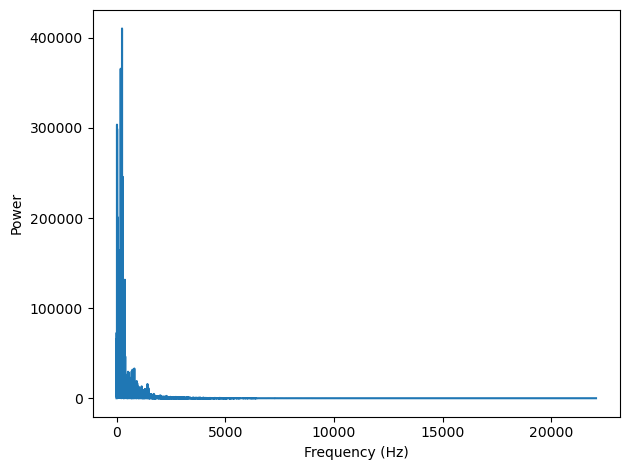

In [30]:
spectrum = segment.make_spectrum()
spectrum.plot_power()
decorate(xlabel="Frequency (Hz)", ylabel="Power")

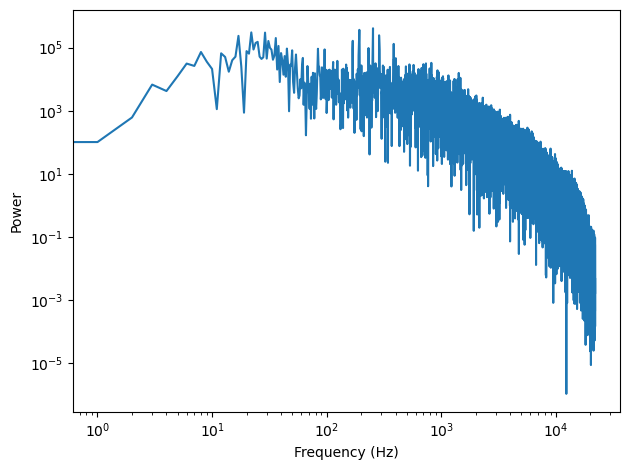

In [31]:
spectrum.plot_power()

loglog = dict(xscale="log", yscale="log")
decorate(xlabel="Frequency (Hz)", ylabel="Power", **loglog)

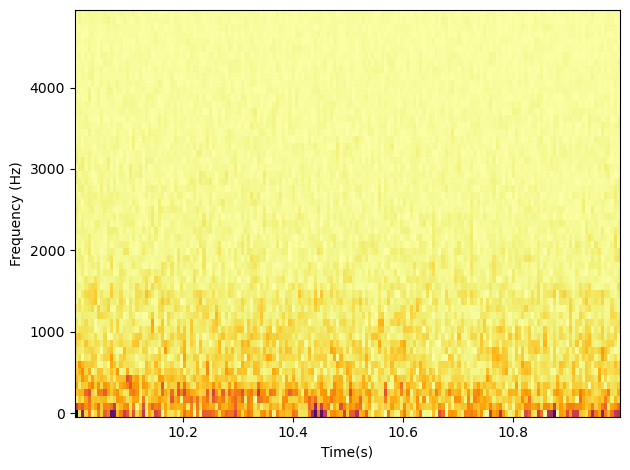

In [32]:
segment.make_spectrogram(512).plot(high=5000)
decorate(xlabel="Time(s)", ylabel="Frequency (Hz)")

## Упражнение 4.2

In [33]:
from thinkdsp import Spectrum


def bartlett_method(wave, seg_length=512, win_flag=True):
    spectrogram = wave.make_spectrogram(seg_length, win_flag)
    spectrums = spectrogram.spec_map.values()

    psds = [spectrum.power for spectrum in spectrums]

    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs

    spectrum = Spectrum(hs, fs, wave.framerate)
    return spectrum

## Упражнение 4.3

In [34]:
import pandas as pd

df = pd.read_csv("data_BTC.csv", parse_dates=[0])
df

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2354,BTC,2020-03-22,5884.340133,6187.042146,6431.873162,5802.553402
2355,BTC,2020-03-23,6455.454688,5829.352511,6620.858253,5694.198299
2356,BTC,2020-03-24,6784.318011,6455.450650,6863.602196,6406.037439
2357,BTC,2020-03-25,6706.985089,6784.325204,6981.720386,6488.111885


In [35]:
ys = df["Closing Price (USD)"]
ts = df.index

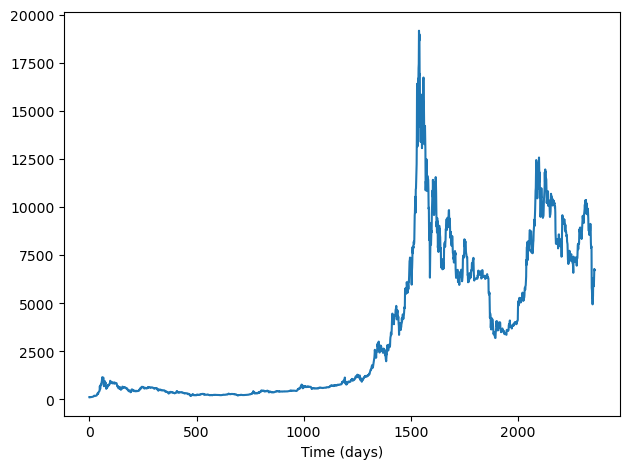

In [36]:
from thinkdsp import Wave

wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel="Time (days)")

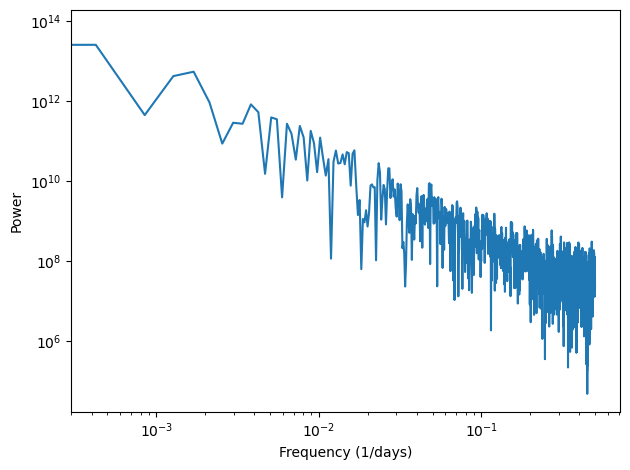

In [37]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel="Frequency (1/days)", ylabel="Power", **loglog)

## Упражнение 4.4

In [ ]:
from thinkdsp import Noise
import numpy as np


class UncorrelatedPoissonNoise(Noise):

    def evaluate(self, ts):
        ys = np.random.poisson(self.amp, len(ts))
        return ys

In [39]:
amp = 0.001
framerate = 10000
duration = 1

signal = UncorrelatedPoissonNoise(amp=amp)
wave = signal.make_wave(duration=duration, framerate=framerate)
wave.make_audio()

In [40]:
expected = amp * framerate * duration
actual = sum(wave.ys)
print(expected, actual)

10.0 5


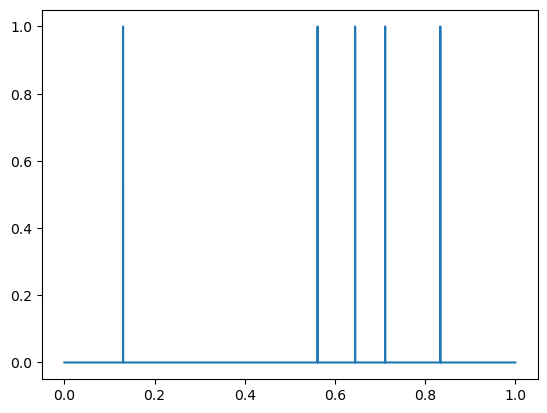

In [41]:
wave.plot()

## Упражнение 4.5

In [ ]:
def voss(nrows, ncols=16):
    """Generates pink noise using the Voss-McCartney algorithm.

    nrows: number of values to generate
    rcols: number of random sources to add

    returns: NumPy array
    """
    array = np.empty((nrows, ncols))
    array.fill(np.nan)
    array[0, :] = np.random.random(ncols)
    array[:, 0] = np.random.random(nrows)

    # the total number of changes is nrows
    n = nrows
    cols = np.random.geometric(0.5, n)
    cols[cols >= ncols] = 0
    rows = np.random.randint(nrows, size=n)
    array[rows, cols] = np.random.random(n)

    df = pd.DataFrame(array)
    df.fillna(method="ffill", axis=0, inplace=True)
    total = df.sum(axis=1)

    return total.values

In [43]:
ys = voss(11025)
ys

C:\Users\egori\AppData\Local\Temp\ipykernel_9140\3490760828.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


array([6.24027893, 6.02876395, 6.91140953, ..., 8.14808562, 8.0680571 ,
       8.49580099], shape=(11025,))

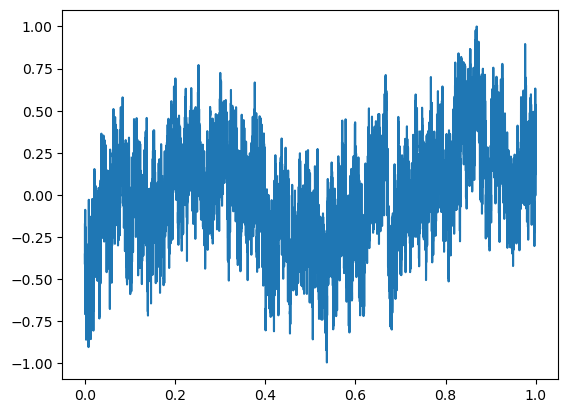

In [45]:
wave = Wave(ys)
wave.unbias()
wave.normalize()
wave.plot()

In [46]:
wave.make_audio()

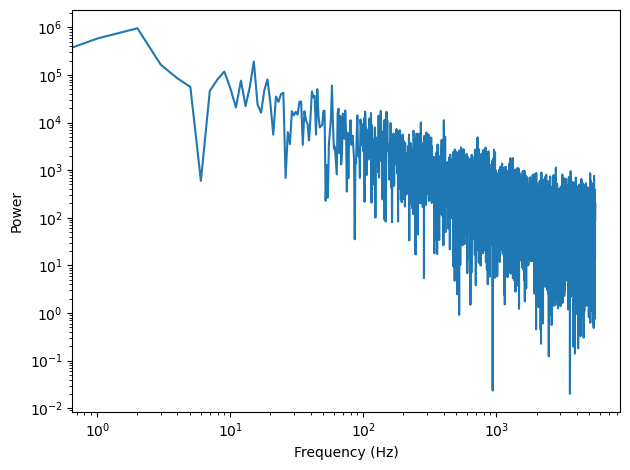

In [47]:
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
spectrum.plot_power()
decorate(xlabel="Frequency (Hz)", ylabel="Power", **loglog)